In [2]:
# import any required  packages here

import mat73
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pandas as pd
import sklearn as sk
from statistics import mean
from sklearn.linear_model import LinearRegression
from scipy.signal import butter, lfilter, iirnotch

In [3]:
# subject demographic information from the dataset paper
# there are a total of 10 participants

mass = np.array([63.49, 63.49, 71.2, 68.03, 68.03, 68.03, 95.24, 65.76, 68.93, 58.05]) # [kg]
height = np.array([1.85, 1.77, 1.73, 1.68, 1.83, 1.85, 1.85, 1.85, 1.73, 1.63]) # [m]
age = np.array([30, 25, 24, 25, 24, 25, 24, 33, 37, 27]) # [years]
sex = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 1]) # 0 = male, 1 = female

In [4]:
# creating a dictionary for all of the activities
# more a convenience than anything

thisdict = {
    "activity": ["Walking", "Incline", "Backwards", "Running", "Cycling", "Stairs", "Standing", "Sitting"],
    "Wspeed": ["0.6", "0.9", "1.2"],
    "Iangle": ["4", "9"],
    "Ispeed": ["0.6", "1.2"],
    "Bspeed": ["0.4", "0.7", "1"],
    "Rspeed": ["1.2", "1.8", "2.2", "2.7"],
    "Cinten": ["1", "3", "5"],
    "Cspeed": ["70", "100"],
    "StairI": ["60"]
}

def activityCode(code,thisdict):
    switcher = {
        1: [thisdict["activity"][0], "at", thisdict["Wspeed"][0], "m/s"],
        2: [thisdict["activity"][0], "at", thisdict["Wspeed"][1], "m/s"],
        3: [thisdict["activity"][0], "at", thisdict["Wspeed"][2], "m/s"],
        4: [thisdict["activity"][1], "at", thisdict["Ispeed"][0], "m/s", "at", thisdict["Iangle"][0], "deg"],
        5: [thisdict["activity"][1], "at", thisdict["Ispeed"][1], "m/s", "at", thisdict["Iangle"][0], "deg"],
        6: [thisdict["activity"][1], "at", thisdict["Ispeed"][0], "m/s", "at", thisdict["Iangle"][1], "deg"],
        7: [thisdict["activity"][1], "at", thisdict["Ispeed"][1], "m/s", "at", thisdict["Iangle"][1], "deg"],
        8: [thisdict["activity"][2], "at", thisdict["Bspeed"][0], "m/s"],
        9: [thisdict["activity"][2], "at", thisdict["Bspeed"][1], "m/s"],
        10: [thisdict["activity"][2], "at", thisdict["Bspeed"][2], "m/s"],
        11: [thisdict["activity"][0], "at", thisdict["Rspeed"][0], "m/s"],
        12: [thisdict["activity"][3], "at", thisdict["Rspeed"][1], "m/s"],
        13: [thisdict["activity"][3], "at", thisdict["Rspeed"][2], "m/s"],
        14: [thisdict["activity"][3], "at", thisdict["Rspeed"][3], "m/s"],
        15: [thisdict["activity"][4], "at", thisdict["Cspeed"][0], "rpm", "at Resistance", thisdict["Cinten"][0]],
        16: [thisdict["activity"][4], "at", thisdict["Cspeed"][0], "rpm", "at Resistance", thisdict["Cinten"][1]],
        17: [thisdict["activity"][4], "at", thisdict["Cspeed"][0], "rpm", "at Resistance", thisdict["Cinten"][2]],
        18: [thisdict["activity"][4], "at", thisdict["Cspeed"][1], "rpm", "at Resistance", thisdict["Cinten"][0]],
        19: [thisdict["activity"][5], "at", thisdict["StairI"][0], "W"],
        20: [thisdict["activity"][5], "at", thisdict["StairI"][0], "W"],
        21: [thisdict["activity"][5], "at", thisdict["StairI"][0], "W"],
        22: thisdict["activity"][6],
        23: thisdict["activity"][7]
    }
    
    my_list = switcher.get(code, "Invalid code")
    if my_list=="Invalid code":
        my_string = my_list
    elif code < 22:
        my_string = " ".join(my_list)
    else:
        my_string = my_list

    return my_string
    
print(activityCode(1,thisdict))

Walking at 0.6 m/s


56 APDM_Accel signals

- 0: time
- 1: activity code
- 2-10: Waist signals
- 11-19: Chest signals
- 20-28: Left Ankle signals
- 29-37: Right Ankle signals
- 38-46: Left Foot signals
- 47-55: Right Foot signals

Within the APDM_Accel sensor signals
- 0-2: acceleration
- 3-5: angular velocity
- 6-8: magnetic field

In [5]:
# indices for different elements within APDM_Accel

time = 0 # same index for all
code = 1 # same index for all
waist = [2, 11]
chest = [11, 20]
Lshnk = [20, 29]
Rshnk = [29, 38]
Lfoot = [38, 47]
Rfoot = [47, 56]

acc = [0, 3]
ang = [3, 6]
mag = [6, 9]

18 EMG signals

- 0: time
- 1: activity code
- 2-9: right leg
- 10-17: left leg

Within right/left leg
- [2,10]: gluteus maximus
- [3,11]: rectus femoris
- [4,12]: vastus lateralis
- [5,13]: semitendinosis
- [6,14]: biceps femoris
- [7,15]: medial gastrocnemius
- [8,16]: soleus
- [9,17]: tibialis anterior


In [6]:
# indices for different elements within EMG

Rleg = [2, 10]
Lleg = [10, 18]

glut = 2
rect = 3
vast = 4
semi = 5
bicfem = 6
gastroc = 7
sol = 8
TA = 9

EMGdiff = 8

8 Empatica Accel signals

- 0: time
- 1: activity code
- 2-4: left wrist accel
- 5-7: right wrist accel

In [7]:
# indices for different elements within Empatica_Accel

Lwrist = [2,5]
Rwrist = [5,8]

6 Empatica Physiological signals

- 0: time
- 1: activity code
- 2-3: left wrist
- 4-5: right wrist

Within left/right wrist
- [2,4]: electrodermal activity (EDA)
- [3,5]: skin temperature

In [8]:

# indices for different elements within Empatica_Physio

Lwrist = [2,4]
Rwrist = [4,6]

EDA = 2
temp = 3

PHYdiff = 2

ACC data on
- Waist, Chest, Left Shank, Right Shank, Left Foot, Right Foot, Right Wrist, Left Wrist

ANGVEL data on
- Waist, Chest, Left Shank, Right Shank, Left Foot, Right Foot

9 Metabolics System signals

- 0: time
- 1: activity code
- 2: VO2
- 3: VCO2
- 4: RER
- 5: breath frequency
- 6: minute ventiltation
- 7: oxygen saturation (SpO2)
- 8: heart rate

In [9]:
# indices for different elements within Metabolics_System

vo2 = 2
vco2 = 3
rer = 4
brefr = 5
minVent = 6
spo2 = 7
hr = 8

In [10]:
# import the data 
# switch folders to be compatible with your computer

mat_fname01 = '/Users/katiebutler/Downloads/HIR Lab/Complete DataSet/Subject01.mat'
mat_fname02 = '/Users/katiebutler/Downloads/HIR Lab/Complete DataSet/Subject02.mat'
mat_fname03 = '/Users/katiebutler/Downloads/HIR Lab/Complete DataSet/Subject03.mat'
mat_fname04 = '/Users/katiebutler/Downloads/HIR Lab/Complete DataSet/Subject04.mat'
mat_fname05 = '/Users/katiebutler/Downloads/HIR Lab/Complete DataSet/Subject05.mat'
mat_fname06 = '/Users/katiebutler/Downloads/HIR Lab/Complete DataSet/Subject06.mat'
mat_fname07 = '/Users/katiebutler/Downloads/HIR Lab/Complete DataSet/Subject07.mat'
mat_fname08 = '/Users/katiebutler/Downloads/HIR Lab/Complete DataSet/Subject08.mat'
mat_fname09 = '/Users/katiebutler/Downloads/HIR Lab/Complete DataSet/Subject09.mat'
mat_fname10 = '/Users/katiebutler/Downloads/HIR Lab/Complete DataSet/Subject10.mat'

mat_contents01 = mat73.loadmat(mat_fname01)
mat_contents02 = mat73.loadmat(mat_fname02)
mat_contents03 = mat73.loadmat(mat_fname03)
mat_contents04 = mat73.loadmat(mat_fname04)
mat_contents05 = mat73.loadmat(mat_fname05)
mat_contents06 = mat73.loadmat(mat_fname06)
mat_contents07 = mat73.loadmat(mat_fname07)
mat_contents08 = mat73.loadmat(mat_fname08)
mat_contents09 = mat73.loadmat(mat_fname09)
mat_contents10 = mat73.loadmat(mat_fname10)

# playing around with the dataframe to make sure I understand how everything is organized here

df1 = pd.DataFrame.from_dict(mat_contents01)
df2 = pd.DataFrame.from_dict(mat_contents02)
df3 = pd.DataFrame.from_dict(mat_contents03)
df4 = pd.DataFrame.from_dict(mat_contents04)
df5 = pd.DataFrame.from_dict(mat_contents05)
df6 = pd.DataFrame.from_dict(mat_contents06)
df7 = pd.DataFrame.from_dict(mat_contents07)
df8 = pd.DataFrame.from_dict(mat_contents08)
df9 = pd.DataFrame.from_dict(mat_contents09)
df10 = pd.DataFrame.from_dict(mat_contents10)

print("Column headers:", list(mat_contents01['Subject01']['Walking']))
 
print(df1['Subject01']['Walking']['Empatica_Physio']['Labels'])
# display(df1)
#print(df1[Subject01])

# plt.plot(df1['Subject01']['Backwards']['APDM_Accel']['Data'][:,0],df1['Subject01']['Backwards']['APDM_Accel']['Data'][:,2:5])
#plt.show()

Column headers: ['APDM_Accel', 'EMG', 'Empatica_Accel', 'Empatica_Physio', 'Metabolics_System']
[['Time (s)', 'Activity Code', 'Left Wrist', 'Left Wrist', 'Right Wrist', 'Right Wrist'], [' ', ' ', 'Electrodermal Activity (uS)', 'Skin Temperature (degC)', 'Electrodermal Activity (uS)', 'Skin Temperature (degC)']]


In [11]:
result = pd.concat([df1["Subject01"], df2["Subject02"], df3["Subject03"], df4["Subject04"], df5["Subject05"], df6["Subject06"], df7["Subject07"], df8["Subject08"], df9["Subject09"], df10["Subject10"]], keys=["Subject01", "Subject02", "Subject03", "Subject04", "Subject05", "Subject06", "Subject07", "Subject08", "Subject09", "Subject10"])
print(result)

Subject01  Backwards    {'APDM_Accel': {'Data': [[ 7.81219484e-03  2.2...
           Cycling      {'APDM_Accel': {'Data': [[ 7.81219484e-03  2.3...
           Incline      {'APDM_Accel': {'Data': [[ 7.81219484e-03  2.2...
           Running      {'APDM_Accel': {'Data': [[ 7.81219484e-03  2.2...
           Walking      {'APDM_Accel': {'Data': [[ 7.81219484e-03  2.2...
                                              ...                        
Subject10  Cycling      {'APDM_Accel': {'Data': [[ 7.81219484e-03  2.3...
           Incline      {'APDM_Accel': {'Data': [[ 7.81219484e-03  2.2...
           Running      {'APDM_Accel': {'Data': [[ 7.81219484e-03  2.2...
           Stairs       {'APDM_Accel': {'Data': [[ 7.81219484e-03  2.2...
           Walking      {'APDM_Accel': {'Data': [[ 7.81219484e-03  2.2...
Length: 61, dtype: object


Levels for the datafile
- SubjectXX
    - Backwards, Cycling, Incline, Running, Walking
        - APDM_Accel, EMG, Empatica_Accel, Empatica_Physio, Metabolics_System
            - Data, Labels, SamplingRate

# For everything below, we will need to loop through all activities and all subjects

In [12]:
# calculate energy expenditure according to oxygen uptake and carbon dioxide produced

VO2 = result['Subject01']['Running']['Metabolics_System']['Data'][:,vo2]
VCO2 = result['Subject01']['Running']['Metabolics_System']['Data'][:,vco2]

EE = (16.58*VO2 + 4.15*VCO2)/mass[0]
EE_ground = np.zeros(np.size(EE))

In [13]:
# need to separate out each phase of the test
# ground truth EE is the average of the last three minutes of each phase

ind = result['Subject01']['Running']['Metabolics_System']['Data'][:,code]
ind = ind[0:-1] - ind[1:]
bool_ind = ind != 0.

indShift = np.where(bool_ind)[0] # last index for each phase
indShift = np.concatenate((indShift, [len(ind)]))

for i in range(0,len(indShift)):
    T = result['Subject01']['Running']['Metabolics_System']['Data'][indShift[i],0]
    timeM3 = T - (3*60)
    bool_time = result['Subject01']['Running']['Metabolics_System']['Data'][:,0] < timeM3
    threeMin = indShift[i] - np.max(np.where(bool_time)[0])
    
    if i == 0:
        EE_ground[0:indShift[i]] = np.mean(EE[indShift[i]-threeMin:indShift[i]])
    elif i == len(indShift)-1:
        EE_ground[indShift[i-1]:] = np.mean(EE[-threeMin:])
    else:
        EE_ground[indShift[i-1]:indShift[i]+1] = np.mean(EE[indShift[i]-threeMin:indShift[i]])
print(EE_ground)

[ 1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196  1.37606196
  1.37606196  1.37606196  1.37606196  1.37606196  1

In [14]:
ind = result['Subject01']['Running']['Metabolics_System']['Data'][:, code]
ind = ind[0:-1] - ind[1:]
bool_ind = ind != 0.

indShift = np.where(bool_ind)[0]  # last index for each phase
indShift = np.concatenate((indShift, [len(ind)]))

# Step 1: Calculate the average of the last 3 minutes of the first 6-minute period
T_first_phase = result['Subject01']['Running']['Metabolics_System']['Data'][indShift[0], 0]
timeM3_first = T_first_phase - (3 * 60)
bool_time_first = result['Subject01']['Running']['Metabolics_System']['Data'][:, 0] < timeM3_first
threeMin_first = indShift[0] - np.max(np.where(bool_time_first)[0])

# Calculate the ground truth EE for the first 6-minute period's last 3 minutes
EE_avg_first = np.mean(EE[indShift[0] - threeMin_first:indShift[0]])
 
for i in range(0, len(indShift)):
    T = result['Subject01']['Running']['Metabolics_System']['Data'][indShift[i], 0]
    timeM3 = T - (3 * 60)
    bool_time = result['Subject01']['Running']['Metabolics_System']['Data'][:, 0] < timeM3
    threeMin = indShift[i] - np.max(np.where(bool_time)[0])
    
    if i == 0:
        EE_ground[0:indShift[i]] = np.mean(EE[indShift[i] - threeMin:indShift[i]]) - EE_avg_first
    elif i == len(indShift) - 1:
        EE_ground[indShift[i - 1]:] = np.mean(EE[-threeMin:]) - EE_avg_first
    else:
        EE_ground[indShift[i - 1]:indShift[i] + 1] = np.mean(EE[indShift[i] - threeMin:indShift[i]]) - EE_avg_first
print(EE_ground)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         2.18054276 2.18054276 2.18054276 2.18054276
 2.18054276 2.18054276 2.18054276 2.18054276 2.1

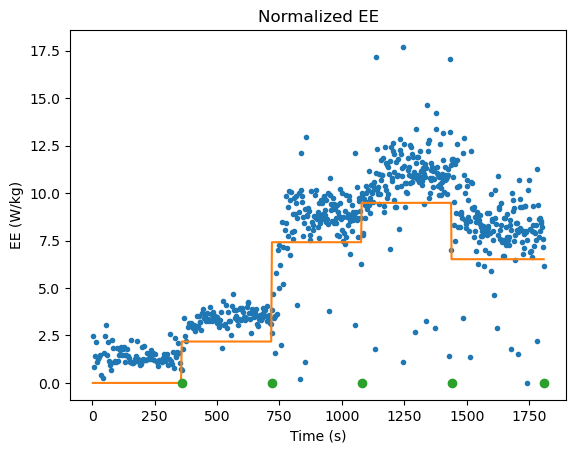

In [15]:
# plotting the EE results
# this is what we are trying to recreate with the wearable sensor data

plt.plot(result['Subject01']['Running']['Metabolics_System']['Data'][:,time], EE, '.', label='EE')
plt.plot(result['Subject01']['Running']['Metabolics_System']['Data'][:,time], EE_ground, '-', label='EE_ground')
plt.plot(result['Subject01']['Running']['Metabolics_System']['Data'][indShift,time], np.zeros(np.size(indShift)), 'o', label='ind')
plt.ylabel('EE (W/kg)')
plt.xlabel('Time (s)')
plt.title('Normalized EE')
plt.show()

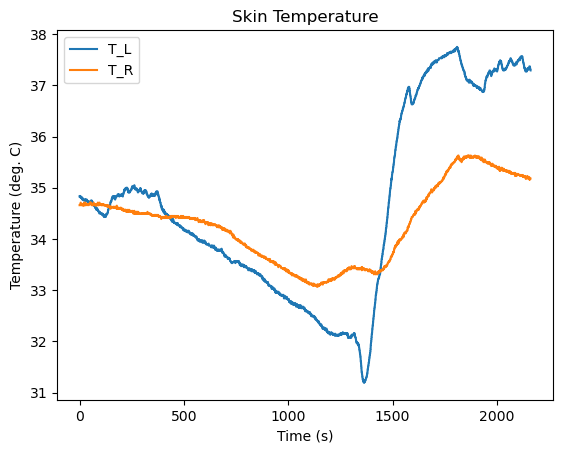

In [27]:
# starting off with some plotting for data exploration

# plt.plot(df2['Subject02']['Running']['Empatica_Physio']['Data'][:,time],df2['Subject02']['Running']['Empatica_Physio']['Data'][:,2], label='EDA_L')
# plt.plot(df2['Subject02']['Running']['Empatica_Physio']['Data'][:,time],df2['Subject02']['Walking']['Empatica_Physio']['Data'][:,4], label='EDA_R')
# plt.legend()
# plt.title("Electrodermal Activity")
# plt.show()

plt.plot(df5['Subject05']['Running']['Empatica_Physio']['Data'][:,time],df5['Subject05']['Running']['Empatica_Physio']['Data'][:,3], label='T_L')
plt.plot(df5['Subject05']['Running']['Empatica_Physio']['Data'][:,time],df5['Subject05']['Running']['Empatica_Physio']['Data'][:,5], label='T_R')
plt.legend()
plt.ylabel('Temperature (deg. C)')
plt.xlabel('Time (s)')
plt.title("Skin Temperature")
plt.show()


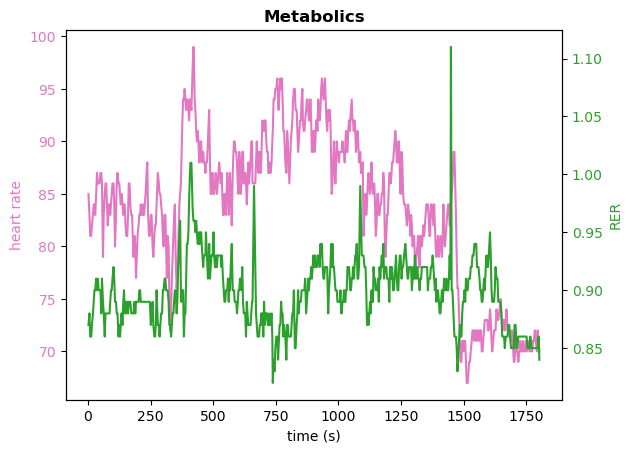

In [15]:
# plotting two things at once to see relationships with respect to time
fig, ax1 = plt.subplots() 
 
color = 'tab:pink'
ax1.set_xlabel('time (s)') 
ax1.set_ylabel('heart rate', color = color) 
ax1.plot(df1['Subject01']['Walking']['Metabolics_System']['Data'][:,time], df1['Subject01']['Walking']['Metabolics_System']['Data'][:,hr], color = color) 
ax1.tick_params(axis ='y', labelcolor = color) 
 
# Adding Twin Axes to plot using dataset_2
ax2 = ax1.twinx() 
 
color = 'tab:green'
ax2.set_ylabel('RER', color = color) 
ax2.plot(df1['Subject01']['Walking']['Metabolics_System']['Data'][:,time], df1['Subject01']['Walking']['Metabolics_System']['Data'][:,rer], color = color) 
ax2.tick_params(axis ='y', labelcolor = color) 
 
# Adding title
plt.title('Metabolics', fontweight ="bold") 
 
# Show plot
plt.show()



In [ ]:
# correlations
# different data sources have different sampling frequencies so need to find common points in time
Tinter, Empind, EEind = np.intersect1d(result['Subject01']['Walking']['Empatica_Physio']['Data'][:,time], result['Subject01']['Walking']['Metabolics_System']['Data'][:,time], return_indices=True)
r = sp.stats.pearsonr(result['Subject01']['Walking']['Empatica_Physio']['Data'][Empind,4], EE_ground[EEind])
print(r)

In [ ]:
# plotting correlations
plt.plot(result['Subject01']['Walking']['Metabolics_System']['Data'][:,rer], EE_ground[EEind], '.')
plt.title("Correlation")
plt.xlabel("EE ground truth")
plt.ylabel("EDA right")
plt.show()

In [ ]:
fig, ax1 = plt.subplots() 

color = 'tab:pink'
ax1.set_xlabel('time (s)') 
ax1.set_ylabel('Accel (m/s^2)', color = color) 
ax1.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,20], color = color)
ax1.tick_params(axis ='y', labelcolor = color) 
 
# Adding Twin Axes to plot using dataset_2
ax2 = ax1.twinx() 
 
color = 'tab:green'
ax2.set_ylabel('Angular Velocity (m/s)', color = color) 
ax2.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,23], color = color)
ax2.tick_params(axis ='y', labelcolor = color) 


plt.xlabel('time (s)')
plt.title('X-Accel of Left Ankle')
plt.show()

fig, ax1 = plt.subplots() 

color = 'tab:pink'
ax1.set_xlabel('time (s)') 
ax1.set_ylabel('Accel (m/s^2)', color = color) 
ax1.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,29], color = color)
ax1.tick_params(axis ='y', labelcolor = color) 
 
# Adding Twin Axes to plot using dataset_2
ax2 = ax1.twinx() 
 
color = 'tab:green'
ax2.set_ylabel('Angular Velocity (m/s)', color = color) 
ax2.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,32], color = color)
ax2.tick_params(axis ='y', labelcolor = color) 


plt.xlabel('time (s)')
plt.title('X-Accel of Right Ankle')
plt.show()

In [ ]:
fig, ax1 = plt.subplots() 

color = 'tab:pink'
ax1.set_xlabel('time (s)') 
ax1.set_ylabel('Accel (m/s^2)', color = color) 
ax1.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,2], color = color)
ax1.tick_params(axis ='y', labelcolor = color) 
 
# Adding Twin Axes to plot using dataset_2
ax2 = ax1.twinx() 
 
color = 'tab:green'
ax2.set_ylabel('Angular Velocity (m/s)', color = color) 
ax2.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject01']['Walking']['APDM_Accel']['Data'][100000:101000,5], color = color)
ax2.tick_params(axis ='y', labelcolor = color) 


plt.xlabel('time (s)')
plt.title('X-Accel of Waist')
plt.show()

In [ ]:

fig, ax1 = plt.subplots() 

color = 'tab:pink'
ax1.set_xlabel('time (s)') 
ax1.set_ylabel('Accel (m/s^2)', color = color)
ax1.plot(result['Subject06']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject06']['Walking']['APDM_Accel']['Data'][100000:101000,39], color = color)
ax1.tick_params(axis ='y', labelcolor = color) 
 
# Adding Twin Axes to plot using dataset_2
ax2 = ax1.twinx() 
 
color = 'tab:green'
ax2.set_ylabel('Angular Velocity (m/s)', color = color) 
ax2.plot(result['Subject06']['Walking']['APDM_Accel']['Data'][100000:101000,time],result['Subject06']['Walking']['APDM_Accel']['Data'][100000:101000,42], color = color)
ax2.tick_params(axis ='y', labelcolor = color) 

plt.xlabel('time (s)')
plt.title('X-Accel of Left Foot')
plt.show()

In [ ]:
# NOT ACCURATE - DO NOT USE - DOES NOT CONSIDER MOMENT OF INERTIA
analyzed = set()

for subject in result.keys():   
    totalKE = 0

    # check if subject was already analyzed
    if subject[0] in analyzed:
        continue
    I = 1
    print(subject[0] + "\n" + "-----------")
    
    analyzed.add(subject[0])
    
    activities = ["Walking", "Incline", "Backwards", "Running", "Cycling", "Stairs"]
    for activity in activities:
        keArray = []
        if (subject[0], activity) not in result:
            print(f"{subject[0]} did not perform {activity}.")
            continue 
        
        for bI in range(5, 56, 9):
            xI = bI
            yI = bI + 1
            zI = bI + 2
            
            x = np.nan_to_num(mean(result[(subject[0], activity)]['APDM_Accel']['Data'][:, xI]), nan=0.0)
            y = np.nan_to_num(mean(result[(subject[0], activity)]['APDM_Accel']['Data'][:, yI]), nan=0.0)
            z = np.nan_to_num(mean(result[(subject[0], activity)]['APDM_Accel']['Data'][:, zI]), nan=0.0)
            
            omega = (x**2 + y**2 + z**2)**0.5
            KE = 0.5*I*omega**2
            keArray.append(KE)
        totalKE = sum(keArray)
        print(f"{activity}: KE = {totalKE}")
    # totalKE = sum(keArray)
    # print(f"Total KE: {totalKE}")
    print("\n")

In [ ]:
# NOT ACCURATE - DO NOT USE - DOES NOT CONSIDER MOMENT OF INERTIA
I = 70
x = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 5]), nan=0.0)
y = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 6]), nan=0.0)
z = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 7]), nan=0.0)

omega = (x**2 + y**2 + z**2)**0.5
KE = 0.5*I*omega**2
KE_df = pd.DataFrame(KE, columns=['KE'])
print(KE_df.describe())
mode_KE = KE_df['KE'].mode()
print("Mode KE:", mode_KE[0])
print(KE)


x1 = np.nan_to_num(mean(result['Subject01']['Walking']['APDM_Accel']['Data'][46080:92160, 5]), nan=0.0)
y1 = np.nan_to_num(mean(result['Subject01']['Walking']['APDM_Accel']['Data'][46080:92160, 6]), nan=0.0)
z1 = np.nan_to_num(mean(result['Subject01']['Walking']['APDM_Accel']['Data'][46080:92160, 7]), nan=0.0)

omega1 = np.sqrt(x1**2 + y1**2 + z1**2)
KE1 = 0.5*I*omega1**2
print(KE1)

x2 = np.nan_to_num(mean(result['Subject01']['Walking']['APDM_Accel']['Data'][92160:138112, 5]), nan=0.0)
y2 = np.nan_to_num(mean(result['Subject01']['Walking']['APDM_Accel']['Data'][92160:138112, 6]), nan=0.0)
z2 = np.nan_to_num(mean(result['Subject01']['Walking']['APDM_Accel']['Data'][92160:138112, 7]), nan=0.0)

omega2 = np.sqrt(x2**2 + y2**2 + z2**2)
KE2 = 0.5*I*omega2**2
print(KE2)

x3 = np.nan_to_num(mean(result['Subject01']['Walking']['APDM_Accel']['Data'][138112:184064, 5]), nan=0.0)
y3 = np.nan_to_num(mean(result['Subject01']['Walking']['APDM_Accel']['Data'][138112:184064, 6]), nan=0.0)
z3 = np.nan_to_num(mean(result['Subject01']['Walking']['APDM_Accel']['Data'][138112:184064, 7]), nan=0.0)

omega3 = np.sqrt(x3**2 + y3**2 + z3**2)
KE3 = 0.5*I*omega3**2
print(KE3)


timeCoords = result['Subject01']['Walking']['Metabolics_System']['Data'][indShift, 0]
print(timeCoords)
# multiply by 128 for sampling frequency 

timeF = result['Subject01']['Walking']['APDM_Accel']['Data'][:,0]

plt.plot(timeF,KE)
plt.plot(result['Subject01']['Walking']['Metabolics_System']['Data'][indShift,0], np.zeros(np.size(indShift)), 'o', label='ind')
# plt.plot(result['Subject01']['Walking']['APDM_Accel']['Data'][:,0], '-', KE)
plt.plot(KE1, 'r-')
plt.plot(KE2, 'r-')
plt.plot(KE3, 'r-')
plt.xlabel('time (s)')
plt.ylabel('kinetic energy (W)')
plt.title('Kinetic Energy while Walking')

print(result['Subject01']['Walking']['APDM_Accel']['SamplingRate'])

In [ ]:
Iw = 0.02654
x = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 5]), nan=0.0)
y = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 6]), nan=0.0)
z = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 7]), nan=0.0)

omega = (x**2 + y**2 + z**2)**0.5
KE = 0.5*Iw*omega**2
KE_df = pd.DataFrame(KE, columns=['KE'])
# print(KE_df)

KE1_df = KE_df.iloc[46080:92160]
KE1_mean = round(KE1_df.mean().values[0], 4)
print(f"KE1: {KE1_mean}")

KE2_df = KE_df.iloc[92160:138112]
KE2_mean = round(KE2_df.mean().values[0], 4)
print(f"KE2: {KE2_mean}")

KE3_df = KE_df.iloc[138112:184064]
KE3_mean = round(KE3_df.mean().values[0],4)
print(f"KE3: {KE3_mean}")

# timeCoords = result['Subject01']['Walking']['Metabolics_System']['Data'][indShift, 0]

timeF = result['Subject01']['Walking']['APDM_Accel']['Data'][:,0]

zeros = {
    'Switch': [46080,92160,138112,184064]
}

zeros_df = pd.DataFrame(zeros)
time_slice = timeF[46080:184064]
KE_slice = KE[46080:184064]

x = [360,720,1079,1438]
y = [KE1_mean,KE2_mean,KE3_mean,KE3_mean] 

plt.plot(time_slice, KE_slice, color='green')
plt.scatter(timeF[zeros_df['Switch']], [0]*len(zeros_df['Switch']), color='black', marker='o')
plt.step(x, y, where='post',color='black')
for i in range(len(x) - 1):
    plt.text(x[i] + 200, y[i] + 0, f'{y[i]}', ha='center', va='bottom')
plt.xlabel('time (s)')
plt.ylabel('kinetic energy (W)')



In [ ]:
Iw = 0.02654 * (1.799/height[0])
xw = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 5]), nan=0.0)
yw = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 6]), nan=0.0)
zw = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 7]), nan=0.0)

omegaw = (xw**2 + yw**2 + zw**2)**0.5
KEw = 0.5*Iw*omegaw**2
KEw_df = pd.DataFrame(KEw, columns=['KE'])
# print(KE_df)

KE1w_df = KEw_df.iloc[46080:92160]
KE1w_mean = round(KE1w_df.mean().values[0], 4)
# print(f"KE1: {KE1w_mean}")

KE2w_df = KEw_df.iloc[92160:138112]
KE2w_mean = round(KE2w_df.mean().values[0], 4)
# print(f"KE2: {KE2w_mean}")

KE3w_df = KEw_df.iloc[138112:184064]
KE3w_mean = round(KE3w_df.mean().values[0],4)
# print(f"KE3: {KE3w_mean}")


Ic = 0.33201 * (1.799/height[0])
xc = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 14]), nan=0.0)
yc = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 15]), nan=0.0)
zc = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 16]), nan=0.0)

omegac = (xc**2 + yc**2 + zc**2)**0.5
KEc = 0.5*Ic*omegac**2
KEc_df = pd.DataFrame(KEc, columns=['KE'])
# print(KE_df)

KE1c_df = KEc_df.iloc[46080:92160]
KE1c_mean = round(KE1c_df.mean().values[0], 4)
# print(f"KE1: {KE1c_mean}")

KE2c_df = KEc_df.iloc[92160:138112]
KE2c_mean = round(KE2c_df.mean().values[0], 4)
# print(f"KE2: {KE2c_mean}")

KE3c_df = KEc_df.iloc[138112:184064]
KE3c_mean = round(KE3c_df.mean().values[0],4)
# print(f"KE3: {KE3c_mean}")



Ial= 0.06397 * (1.799/height[0])
xal = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 23]), nan=0.0)
yal = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 24]), nan=0.0)
zal = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 25]), nan=0.0)

omegaal = (xal**2 + yal**2 + zal**2)**0.5
KEal = 0.5*Iw*omegaal**2
KEal_df = pd.DataFrame(KEal, columns=['KE'])
# print(KE_df)

KE1al_df = KEal_df.iloc[46080:92160]
KE1al_mean = round(KE1al_df.mean().values[0], 4)
# print(f"KE1: {KE1al_mean}")

KE2al_df = KEal_df.iloc[92160:138112]
KE2al_mean = round(KE2al_df.mean().values[0], 4)
# print(f"KE2: {KE2al_mean}")

KE3al_df = KEal_df.iloc[138112:184064]
KE3al_mean = round(KE3al_df.mean().values[0],4)
# print(f"KE3: {KE3al_mean}")


Iar = 0.06271 * (1.799/height[0])
xar = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 32]), nan=0.0)
yar = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 33]), nan=0.0)
zar = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 34]), nan=0.0)

omegaar = (xar**2 + yar**2 + zar**2)**0.5
KEar = 0.5*Iw*omegaar**2
KEar_df = pd.DataFrame(KEar, columns=['KE'])
# print(KE_df)

KE1ar_df = KEar_df.iloc[46080:92160]
KE1ar_mean = KE1ar_df.mean().values[0]
# print(f"KE1: {KE1ar_mean}")

KE2ar_df = KEar_df.iloc[92160:138112]
KE2ar_mean = KE2ar_df.mean().values[0]
# print(f"KE2: {KE2ar_mean}")

KE3ar_df = KEar_df.iloc[138112:184064]
KE3ar_mean = KE3ar_df.mean().values[0]
# print(f"KE3: {KE3ar_mean}")


# timeCoords = result['Subject01']['Walking']['Metabolics_System']['Data'][indShift, 0]

timeF = result['Subject01']['Walking']['APDM_Accel']['Data'][:,0]

zeros = {
    'Switch': [46080,92160,138112,184064]
}

KE = KEw + KEal + KEar


zeros_df = pd.DataFrame(zeros)
time_slice = timeF[46080:184064]
KE_slice = KE[46080:184064]

KE1_mean = round(KE1w_mean + KE1ar_mean + KE1al_mean + KE1c_mean, 4)
KE2_mean = round(KE2w_mean + KE2ar_mean + KE2al_mean + KE2c_mean, 4)
KE3_mean = round(KE3w_mean + KE3ar_mean + KE3al_mean + KE3c_mean, 4)


x = [360,720,1079,1438]
y = [KE1_mean,KE2_mean,KE3_mean,KE3_mean] 

plt.plot(time_slice, KE_slice, color='green')
plt.scatter(timeF[zeros_df['Switch']], [0]*len(zeros_df['Switch']), color='black', marker='o')
plt.step(x, y, where='post',color='black')
for i in range(len(x) - 1):
    plt.text(x[i] + 200, y[i] + 0.02, f'{y[i]}', ha='center', va='bottom')
plt.xlabel('Time (s)')
plt.ylabel('Kinetic Energy (W)')




In [ ]:
fig, ax1 = plt.subplots() 

color = 'tab:blue'
ax1.set_xlabel('Time (s)') 
ax1.set_ylabel('Kinetic Energy (W)', color = color)
ax1.plot(time_slice, KE_slice, color= color)
ax1.tick_params(axis ='y', labelcolor = color)

plt.scatter(timeF[zeros_df['Switch']], [0]*len(zeros_df['Switch']), color='black', marker='o')
plt.step(x, y, where='post',color='black')
for i in range(len(x) - 1):
    plt.text(x[i] + 200, y[i] + 0.02, f'{y[i]}', ha='center', va='bottom')

ax2 = ax1.twinx() 
 
color = 'tab:orange'
ax2.set_ylabel('EE Ground (W/kg)', color = color) 
ax2.plot(result['Subject01']['Walking']['Metabolics_System']['Data'][:,time], EE_ground, '-', label='EE_ground', color= color)
ax2.tick_params(axis ='y', labelcolor = color) 

plt.xlabel('time (s)')
plt.title('Kinetic Energy vs. EE Ground')
plt.show()

In [ ]:
analyzed = set()
kePoints = []
eePoints = []
index = 0
for subject in (result.keys()):
    totalKE = 0
    # check if subject was already analyzed
    if subject[0] in analyzed:
        continue
    
    print(subject[0] + "\n" + "-----------")
    analyzed.add(subject[0])
    # print(index)
    # print(height[index])
    
    mNorm = (mass[index] / 82.2)
        
    index = index + 1
    
    Iw = 0.02654 * mNorm
    xw = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 5]), nan=0.0)
    yw = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 6]), nan=0.0)
    zw = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 7]), nan=0.0)

    omegaw = (xw**2 + yw**2 + zw**2)**0.5
    KEw = 0.5*Iw*omegaw**2
    KEw_df = pd.DataFrame(KEw, columns=['KE'])
    # print(KE_df)

    KE1w_df = KEw_df.iloc[46080:92160]
    KE1w_mean = round(KE1w_df.mean().values[0], 4)
    # print(f"KE1: {KE1w_mean}")

    KE2w_df = KEw_df.iloc[92160:138112]
    KE2w_mean = round(KE2w_df.mean().values[0], 4)
    # print(f"KE2: {KE2w_mean}")

    KE3w_df = KEw_df.iloc[138112:184064]
    KE3w_mean = round(KE3w_df.mean().values[0],4)
    # print(f"KE3: {KE3w_mean}")


    Ic = 0.33201 * mNorm
    xc = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 14]), nan=0.0)
    yc = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 15]), nan=0.0)
    zc = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 16]), nan=0.0)

    omegac = (xc**2 + yc**2 + zc**2)**0.5
    KEc = 0.5*Ic*omegac**2
    KEc_df = pd.DataFrame(KEc, columns=['KE'])
    # print(KE_df)

    KE1c_df = KEc_df.iloc[46080:92160]
    KE1c_mean = round(KE1c_df.mean().values[0], 4)
    # print(f"KE1: {KE1c_mean}")

    KE2c_df = KEc_df.iloc[92160:138112]
    KE2c_mean = round(KE2c_df.mean().values[0], 4)
    # print(f"KE2: {KE2c_mean}")

    KE3c_df = KEc_df.iloc[138112:184064]
    KE3c_mean = round(KE3c_df.mean().values[0],4)
    # print(f"KE3: {KE3c_mean}")



    Ial= 0.06397 * mNorm
    xal = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 23]), nan=0.0)
    yal = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 24]), nan=0.0)
    zal = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 25]), nan=0.0)

    omegaal = (xal**2 + yal**2 + zal**2)**0.5
    KEal = 0.5*Iw*omegaal**2
    KEal_df = pd.DataFrame(KEal, columns=['KE'])
    # print(KE_df)

    KE1al_df = KEal_df.iloc[46080:92160]
    KE1al_mean = round(KE1al_df.mean().values[0], 4)
    # print(f"KE1: {KE1al_mean}")

    KE2al_df = KEal_df.iloc[92160:138112]
    KE2al_mean = round(KE2al_df.mean().values[0], 4)
    # print(f"KE2: {KE2al_mean}")

    KE3al_df = KEal_df.iloc[138112:184064]
    KE3al_mean = round(KE3al_df.mean().values[0],4)
    # print(f"KE3: {KE3al_mean}")


    Iar = 0.06271 * mNorm
    xar = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 32]), nan=0.0)
    yar = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 33]), nan=0.0)
    zar = np.nan_to_num((result[subject[0]]['Walking']['APDM_Accel']['Data'][:, 34]), nan=0.0)

    omegaar = (xar**2 + yar**2 + zar**2)**0.5
    KEar = 0.5*Iw*omegaar**2
    KEar_df = pd.DataFrame(KEar, columns=['KE'])
    # print(KE_df)

    KE1ar_df = KEar_df.iloc[46080:92160]
    KE1ar_mean = KE1ar_df.mean().values[0]
    # print(f"KE1: {KE1ar_mean}")

    KE2ar_df = KEar_df.iloc[92160:138112]
    KE2ar_mean = KE2ar_df.mean().values[0]
    # print(f"KE2: {KE2ar_mean}")

    KE3ar_df = KEar_df.iloc[138112:184064]
    KE3ar_mean = KE3ar_df.mean().values[0]
    # print(f"KE3: {KE3ar_mean}")


    # timeCoords = result['Subject01']['Walking']['Metabolics_System']['Data'][indShift, 0]

    timeF = result[subject[0]]['Walking']['APDM_Accel']['Data'][:,0]

    zeros = {
        'Switch': [46080,92160,138112,184064]
    }

    KE = (KEw + KEc + KEal + KEar) * mNorm


    zeros_df = pd.DataFrame(zeros)
    time_slice = timeF[46080:184064]
    KE_slice = KE[46080:184064]

    KE1_mean = round((KE1w_mean + KE1ar_mean + KE1al_mean + KE1c_mean) * mNorm, 4)
    KE2_mean = round((KE2w_mean + KE2ar_mean + KE2al_mean + KE2c_mean) * mNorm, 4)
    KE3_mean = round((KE3w_mean + KE3ar_mean + KE3al_mean + KE3c_mean) * mNorm, 4)
    
    kePoints.append(KE1_mean)
    kePoints.append(KE2_mean)
    kePoints.append(KE3_mean)

    x = [360,720,1079,1438]
    y = [KE1_mean,KE2_mean,KE3_mean,KE3_mean] 

    fig, ax1 = plt.subplots() 

    ke_slice_start = result[subject[0]]['Walking']['Metabolics_System']['Data'][0, 0] + 46080 / 128
    ke_slice_end = result[subject[0]]['Walking']['Metabolics_System']['Data'][0, 0] + 184064 / 128

    VO2 = result[subject[0]]['Walking']['Metabolics_System']['Data'][:,vo2]
    VCO2 = result[subject[0]]['Walking']['Metabolics_System']['Data'][:,vco2]

    EE = (16.58*VO2 + 4.15*VCO2)/mass[0]
    EE_ground = np.zeros(np.size(EE))

    ind = result[subject[0]]['Walking']['Metabolics_System']['Data'][:,code]
    ind = ind[0:-1] - ind[1:]
    bool_ind = ind != 0.

    indShift = np.where(bool_ind)[0] # last index for each phase
    indShift = np.concatenate((indShift, [len(ind)]))

    for i in range(0,len(indShift)):
        T = result[subject[0]]['Walking']['Metabolics_System']['Data'][indShift[i],0]
        timeM3 = T - (3*60)
        bool_time = result[subject[0]]['Walking']['Metabolics_System']['Data'][:,0] < timeM3
        threeMin = indShift[i] - np.max(np.where(bool_time)[0])

        if i == 0:
            EE_ground[0:indShift[i]] = np.mean(EE[indShift[i]-threeMin:indShift[i]])
            ee1 = round(np.mean(EE[indShift[i]-threeMin:indShift[i]]), 4)
            if ke_slice_start <= T <= ke_slice_end:
                eePoints.append(ee1)
         
        elif i == len(indShift)-1:
            EE_ground[indShift[i-1]:] = np.mean(EE[-threeMin:])
            ee2 = round(np.mean(EE[-threeMin:]), 4)
            if ke_slice_start <= T <= ke_slice_end:
                eePoints.append(ee2)
             
        else:
            EE_ground[indShift[i-1]:indShift[i]+1] = np.mean(EE[indShift[i]-threeMin:indShift[i]])
            ee3 = round(np.mean(EE[indShift[i]-threeMin:indShift[i]]), 4)
            if ke_slice_start <= T <= ke_slice_end:
                eePoints.append(ee3)
       
                

    color = 'tab:blue'
    ax1.set_xlabel('Time (s)') 
    ax1.set_ylabel('Kinetic Energy (W/kg)', color = color)
    ax1.plot(time_slice, KE_slice, color= color)
    ax1.tick_params(axis ='y', labelcolor = color)

    plt.scatter(timeF[zeros_df['Switch']], [0]*len(zeros_df['Switch']), color='black', marker='o')
    plt.step(x, y, where='post',color='black')
    for i in range(len(x) - 1):
        plt.text(x[i] + 200, y[i] + 0.02, f'{y[i]}', ha='center', va='bottom')

    ax2 = ax1.twinx() 

    color = 'tab:orange'
    ax2.set_ylabel('EE Ground (W/kg)', color = color) 
    ax2.plot(result[subject[0]]['Walking']['Metabolics_System']['Data'][:,time], EE_ground, '-', label='EE_ground', color= color)
    ax2.tick_params(axis ='y', labelcolor = color) 

    plt.xlabel('time (s)')
    plt.title('Kinetic Energy vs. EE Ground')
    plt.show()

eePoints.remove(1.4591)
eePoints.insert(8, 4.7)
eePoints.append(4.2)

In [ ]:
x = eePoints
y = kePoints
plt.scatter(x, y)
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)))
plt.xlabel('EE')
plt.ylabel('KE')

coefficients = np.polyfit(x, y, 1)

correlationDf = pd.DataFrame(list(zip(x, y)), columns=['EE', 'KE'])
correlationDf['Coefficient'] = correlationDf['EE']/correlationDf['KE']
display(correlationDf)

In [ ]:
speed1 = correlationDf.iloc[::3]
speed2 = correlationDf.iloc[1::3]
speed3 = correlationDf.iloc[2::3]

plt.scatter(speed1['EE'],speed1['KE'])
plt.plot(np.unique(speed1['EE']), np.poly1d(np.polyfit(speed1['EE'], speed1['KE'], 1))(np.unique(speed1['EE'])))
plt.scatter(speed2['EE'],speed2['KE'])
plt.plot(np.unique(speed2['EE']), np.poly1d(np.polyfit(speed2['EE'], speed2['KE'], 1))(np.unique(speed2['EE'])))
plt.scatter(speed3['EE'],speed3['KE'])
plt.plot(np.unique(speed3['EE']), np.poly1d(np.polyfit(speed3['EE'], speed3['KE'], 1))(np.unique(speed3['EE'])))

print('Speed 1:')
coefficients1 = np.polyfit(speed1['EE'], speed1['KE'], 1)
print(coefficients1)
display(speed1)
print('Speed 2:')
coefficients2 = np.polyfit(speed2['EE'], speed2['KE'], 1)
print(coefficients2)
display(speed2)
print('Speed 3:')
coefficients3 = np.polyfit(speed3['EE'], speed3['KE'], 1)
print(coefficients3)
display(speed3)

plt.xlabel('EE [W/kg]')
plt.ylabel('KE [W]')
plt.title('Kinetic Energy vs. Energy Expenditure')

In [ ]:
subKE = correlationDf

colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'cyan', 'magenta', 'yellow', 'black']

for i in range(0, len(x), 3):
    plt.scatter(subKE['EE'][i:i+3], subKE['KE'][i:i+3], color=colors[i // 3], label=f'S{i//3 + 1}')

    coeffs = np.polyfit(x[i:i+3], y[i:i+3], 1)  # Linear fit
    slope = round(coeffs[0],4)
    print(f'Subject {i//3 + 1} Slope: {slope}')
    poly = np.poly1d(coeffs)
    x_fit = np.linspace(min(x[i:i+3]), max(x[i:i+3]), 100)
    y_fit = poly(x_fit)
    plt.plot(x_fit, y_fit, color=colors[i // 3], linestyle='-')
    
plt.legend()
plt.xlabel('EE [W/kg]')
plt.ylabel('KE [W/kg]')
plt.title('EE vs. KE by Subject - Walking')
plt.show()

In [ ]:
analyzed = set()
for subject in result.keys():   
 # check if subject was already analyzed
    if subject[0] in analyzed:
        continue 
        
    print(subject[0] + "\n" + "-----------")
    
    analyzed.add(subject[0])
    
    LL_EMG = np.nan_to_num((result[subject[0]]['Walking']['EMG']['Data'][:, 2:9]), nan=0.0)
    RL_EMG = np.nan_to_num((result[subject[0]]['Walking']['EMG']['Data'][:, 10:17]), nan=0.0)
    combined_EMG = np.hstack((LL_EMG, RL_EMG))
    avgEMG = np.mean(combined_EMG, axis=1)
    print(avgEMG)

    timeF = result[subject[0]]['Walking']['EMG']['Data'][:,0]
    time_slice = timeF[46080:184064]
    
    def removeDc(signal):
        return signal - np.mean(signal)
    
    LL_EMG = removeDc(LL_EMG)
    RL_EMG = removeDc(RL_EMG)
    
    def notch(signal, freq = 60, fs = 1000, qualityF = 30):
        nyquist = 0.5 * fs
        freq = freq/nyquist
        b, a = iirnotch(freq, qualityF)
        signal = lfilter(b, a, signal)
        return signal

    LL_EMG = notch(LL_EMG)
    RL_EMG = notch(RL_EMG)
    
    def butterworth(lowcut, highcut, fs, order = 4):
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        b, a = butter(order, [low, high], btype = 'band')
        return b, a
    def bandpass(signal, lowcut = 20, highcut = 450, fs = 1000, order = 4):
        b, a = butterworth(lowcut, highcut, fs, order = order)
        filtered_signal = lfilter(b, a, signal)
        return signal
    
    LL_EMG = bandpass(LL_EMG)
    RL_EMG = bandpass(RL_EMG)
    
    
    color = 'tab:blue'
    plt.xlabel('Time (s)') 
    plt.ylabel('EMG', color = color)
    plt.plot(avgEMG, color= color)
    plt.tick_params(axis ='y', labelcolor = color)

    plt.xlabel('time (s)')
    plt.title('Kinetic Energy vs. EE Ground')
    plt.show()
    

In [ ]:
analyzed = set()
kePoints = []
eePoints = []
for subject in result.keys():   
    totalKE = 0

    # check if subject was already analyzed
    if subject[0] in analyzed:
        continue
        
    print(subject[0] + "\n" + "-----------")
    
    analyzed.add(subject[0])
    
    Iw = 0.02654
    xw = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 5]), nan=0.0)
    yw = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 6]), nan=0.0)
    zw = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 7]), nan=0.0)

    omegaw = (xw**2 + yw**2 + zw**2)**0.5
    KEw = 0.5*Iw*omegaw**2
    KEw_df = pd.DataFrame(KEw, columns=['KE'])
    # print(KE_df)

    KE1w_df = KEw_df.iloc[46080:92160]
    KE1w_mean = round(KE1w_df.mean().values[0], 4)
    # print(f"KE1: {KE1w_mean}")

    KE2w_df = KEw_df.iloc[92160:138112]
    KE2w_mean = round(KE2w_df.mean().values[0], 4)
    # print(f"KE2: {KE2w_mean}")

    KE3w_df = KEw_df.iloc[138112:184064]
    KE3w_mean = round(KE3w_df.mean().values[0],4)
    # print(f"KE3: {KE3w_mean}")


    Ic = 0.33201
    xc = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 14]), nan=0.0)
    yc = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 15]), nan=0.0)
    zc = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 16]), nan=0.0)

    omegac = (xc**2 + yc**2 + zc**2)**0.5
    KEc = 0.5*Ic*omegac**2
    KEc_df = pd.DataFrame(KEc, columns=['KE'])
    # print(KE_df)

    KE1c_df = KEc_df.iloc[46080:92160]
    KE1c_mean = round(KE1c_df.mean().values[0], 4)
    # print(f"KE1: {KE1c_mean}")

    KE2c_df = KEc_df.iloc[92160:138112]
    KE2c_mean = round(KE2c_df.mean().values[0], 4)
    # print(f"KE2: {KE2c_mean}")

    KE3c_df = KEc_df.iloc[138112:184064]
    KE3c_mean = round(KE3c_df.mean().values[0],4)
    # print(f"KE3: {KE3c_mean}")



    Ial= 0.06397
    xal = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 23]), nan=0.0)
    yal = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 24]), nan=0.0)
    zal = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 25]), nan=0.0)

    omegaal = (xal**2 + yal**2 + zal**2)**0.5
    KEal = 0.5*Iw*omegaal**2
    KEal_df = pd.DataFrame(KEal, columns=['KE'])
    # print(KE_df)

    KE1al_df = KEal_df.iloc[46080:92160]
    KE1al_mean = round(KE1al_df.mean().values[0], 4)
    # print(f"KE1: {KE1al_mean}")

    KE2al_df = KEal_df.iloc[92160:138112]
    KE2al_mean = round(KE2al_df.mean().values[0], 4)
    # print(f"KE2: {KE2al_mean}")

    KE3al_df = KEal_df.iloc[138112:184064]
    KE3al_mean = round(KE3al_df.mean().values[0],4)
    # print(f"KE3: {KE3al_mean}")


    Iar = 0.06271
    xar = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 32]), nan=0.0)
    yar = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 33]), nan=0.0)
    zar = np.nan_to_num((result[subject[0]]['Backwards']['APDM_Accel']['Data'][:, 34]), nan=0.0)

    omegaar = (xar**2 + yar**2 + zar**2)**0.5
    KEar = 0.5*Iw*omegaar**2
    KEar_df = pd.DataFrame(KEar, columns=['KE'])
    # print(KE_df)

    KE1ar_df = KEar_df.iloc[46080:92160]
    KE1ar_mean = KE1ar_df.mean().values[0]
    # print(f"KE1: {KE1ar_mean}")

    KE2ar_df = KEar_df.iloc[92160:138112]
    KE2ar_mean = KE2ar_df.mean().values[0]
    # print(f"KE2: {KE2ar_mean}")

    KE3ar_df = KEar_df.iloc[138112:184064]
    KE3ar_mean = KE3ar_df.mean().values[0]
    # print(f"KE3: {KE3ar_mean}")


    # timeCoords = result['Subject01']['Walking']['Metabolics_System']['Data'][indShift, 0]

    timeF = result[subject[0]]['Backwards']['APDM_Accel']['Data'][:,0]

    zeros = {
        'Switch': [46080,92160,138112,184064]
    }

    KE = KEw + KEc + KEal + KEar


    zeros_df = pd.DataFrame(zeros)
    time_slice = timeF[46080:184064]
    KE_slice = KE[46080:184064]

    KE1_mean = round(KE1w_mean + KE1ar_mean + KE1al_mean + KE1c_mean, 4)
    KE2_mean = round(KE2w_mean + KE2ar_mean + KE2al_mean + KE2c_mean, 4)
    KE3_mean = round(KE3w_mean + KE3ar_mean + KE3al_mean + KE3c_mean, 4)

    kePoints.append(KE1_mean)
    kePoints.append(KE2_mean)
    kePoints.append(KE3_mean)
    
    ke_slice_start = result[subject[0]]['Backwards']['Metabolics_System']['Data'][0, 0] + 46080 / 128
    ke_slice_end = result[subject[0]]['Backwards']['Metabolics_System']['Data'][0, 0] + 184064 / 128

    VO2 = result[subject[0]]['Backwards']['Metabolics_System']['Data'][:,vo2]
    VCO2 = result[subject[0]]['Backwards']['Metabolics_System']['Data'][:,vco2]

    EE = (16.58*VO2 + 4.15*VCO2)/mass[0]
    EE_ground = np.zeros(np.size(EE))

    ind = result[subject[0]]['Backwards']['Metabolics_System']['Data'][:,code]
    ind = ind[0:-1] - ind[1:]
    bool_ind = ind != 0.

    indShift = np.where(bool_ind)[0] # last index for each phase
    indShift = np.concatenate((indShift, [len(ind)]))

    for i in range(0,len(indShift)):
        T = result[subject[0]]['Backwards']['Metabolics_System']['Data'][indShift[i],0]
        timeM3 = T - (3*60)
        bool_time = result[subject[0]]['Backwards']['Metabolics_System']['Data'][:,0] < timeM3
        threeMin = indShift[i] - np.max(np.where(bool_time)[0])

        if i == 0:
            EE_ground[0:indShift[i]] = np.mean(EE[indShift[i]-threeMin:indShift[i]])
            ee1 = round(np.mean(EE[indShift[i]-threeMin:indShift[i]]), 4)
            if ke_slice_start <= T <= ke_slice_end:
                eePoints.append(ee1)

        elif i == len(indShift)-1:
            EE_ground[indShift[i-1]:] = np.mean(EE[-threeMin:])
            ee2 = round(np.mean(EE[-threeMin:]), 4)
            if ke_slice_start <= T <= ke_slice_end:
                eePoints.append(ee2)

        else:
            EE_ground[indShift[i-1]:indShift[i]+1] = np.mean(EE[indShift[i]-threeMin:indShift[i]])
            ee3 = round(np.mean(EE[indShift[i]-threeMin:indShift[i]]), 4)
            if ke_slice_start <= T <= ke_slice_end:
                eePoints.append(ee3)

    x = [360,720,1079,1438]
    y = [KE1_mean,KE2_mean,KE3_mean,KE3_mean] 

    fig, ax1 = plt.subplots() 

    color = 'tab:blue'
    ax1.set_xlabel('Time (s)') 
    ax1.set_ylabel('Kinetic Energy (W)', color = color)
    ax1.plot(time_slice, KE_slice, color= color)
    ax1.tick_params(axis ='y', labelcolor = color)
    
    valid_indices = zeros_df['Switch'][zeros_df['Switch'] < len(timeF)]
    time_eeGround = result[subject[0]]['Backwards']['Metabolics_System']['Data'][:, 0]
    
    plt.scatter(timeF[valid_indices], [0]*len(valid_indices), color='black', marker='o')
    plt.step(x, y, where='post',color='black')
    for i in range(len(x) - 1):
        plt.text(x[i] + 200, y[i] + 0.02, f'{y[i]}', ha='center', va='bottom')

    ax2 = ax1.twinx() 

    color = 'tab:orange'
    ax2.set_ylabel('EE Ground (W/kg)', color = color) 
    ax2.plot(time_eeGround, EE_ground, '-', label='EE_ground', color= color)
    ax2.tick_params(axis ='y', labelcolor = color) 

    plt.xlabel('time (s)')
    plt.title('Kinetic Energy vs. EE Ground')
    plt.show()

eePoints.insert(4, 3.3625)
eePoints.insert(5, 3.3625)
kePoints[4] = 0.0864
kePoints[5] = 0.0864

In [ ]:
x = eePoints
y = kePoints
print(x)
print(y)
plt.scatter(x, y)
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)))
plt.xlabel('EE')
plt.ylabel('KE')

coefficients = np.polyfit(x, y, 1)

correlationDf = pd.DataFrame(list(zip(x, y)), columns=['EE', 'KE'])
correlationDf['Coefficient'] = correlationDf['EE']/correlationDf['KE']
display(correlationDf)

In [ ]:
subKE = correlationDf

colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'cyan', 'magenta', 'yellow', 'black']

for i in range(0, len(x), 3):
    plt.scatter(subKE['EE'][i:i+3], subKE['KE'][i:i+3], color=colors[i // 3], label=f'S{i//3 + 1}')

    coeffs = np.polyfit(x[i:i+3], y[i:i+3], 1)  # Linear fit
    slope = round(coeffs[0],4)
    print(f'Subject {i//3 + 1} Slope: {slope}')
    poly = np.poly1d(coeffs)
    x_fit = np.linspace(min(x[i:i+3]), max(x[i:i+3]), 100)
    y_fit = poly(x_fit)
    plt.plot(x_fit, y_fit, color=colors[i // 3], linestyle='-')
    
plt.legend()
plt.xlabel('EE [W/kg]')
plt.ylabel('KE [W]')
plt.title('EE vs. KE by Subject - Backwards Walking')
plt.show()

In [ ]:
analyzed = set()
kePoints = []
eePoints = []
for subject in result.keys():   
    totalKE = 0

    # check if subject was already analyzed
    if subject[0] in analyzed:
        continue
        
    print(subject[0] + "\n" + "-----------")
    
    analyzed.add(subject[0])
    
    Iw = 0.02654
    xw = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 5]), nan=0.0)
    yw = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 6]), nan=0.0)
    zw = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 7]), nan=0.0)

    omegaw = (xw**2 + yw**2 + zw**2)**0.5
    KEw = 0.5*Iw*omegaw**2
    KEw_df = pd.DataFrame(KEw, columns=['KE'])
    # print(KE_df)

    KE1w_df = KEw_df.iloc[42960:92160]
    KE1w_mean = KE1w_df.mean().values[0]
    KE2w_df = KEw_df.iloc[92160:137728]
    KE2w_mean = KE2w_df.mean().values[0]
    KE3w_df = KEw_df.iloc[137728:184320]
    KE3w_mean = KE3w_df.mean().values[0]
    KE4w_df = KEw_df.iloc[184320:230400]
    KE4w_mean = KE4w_df.mean().values[0]
    KE5w_df = KEw_df.iloc[230400:276224]
    KE5w_mean = KE5w_df.mean().values[0]
    KE6w_df = KEw_df.iloc[276224:322560]
    KE6w_mean = KE6w_df.mean().values[0]


    Ic = 0.33201
    xc = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 14]), nan=0.0)
    yc = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 15]), nan=0.0)
    zc = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 16]), nan=0.0)

    omegac = (xc**2 + yc**2 + zc**2)**0.5
    KEc = 0.5*Ic*omegac**2
    KEc_df = pd.DataFrame(KEc, columns=['KE'])
    # print(KE_df)

    KE1c_df = KEc_df.iloc[42960:92160]
    KE1c_mean = KE1c_df.mean().values[0]
    KE2c_df = KEc_df.iloc[92160:137728]
    KE2c_mean = KE2c_df.mean().values[0]
    KE3c_df = KEc_df.iloc[137728:184320]
    KE3c_mean = KE3c_df.mean().values[0]
    KE4c_df = KEc_df.iloc[184320:230400]
    KE4c_mean = KE4c_df.mean().values[0]
    KE5c_df = KEc_df.iloc[230400:276224]
    KE5c_mean = KE5c_df.mean().values[0]
    KE6c_df = KEc_df.iloc[276224:322560]
    KE6c_mean = KE6c_df.mean().values[0]



    Ial= 0.06397
    xal = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 23]), nan=0.0)
    yal = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 24]), nan=0.0)
    zal = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 25]), nan=0.0)

    omegaal = (xal**2 + yal**2 + zal**2)**0.5
    KEal = 0.5*Iw*omegaal**2
    KEal_df = pd.DataFrame(KEal, columns=['KE'])
    # print(KE_df)

    KE1al_df = KEal_df.iloc[42960:92160]
    KE1al_mean = KE1al_df.mean().values[0]
    KE2al_df = KEal_df.iloc[92160:137728]
    KE2al_mean = KE2al_df.mean().values[0]
    KE3al_df = KEal_df.iloc[137728:184320]
    KE3al_mean = KE3al_df.mean().values[0]
    KE4al_df = KEal_df.iloc[184320:230400]
    KE4al_mean = KE4al_df.mean().values[0]
    KE5al_df = KEal_df.iloc[230400:276224]
    KE5al_mean = KE5al_df.mean().values[0]
    KE6al_df = KEal_df.iloc[276224:322560]
    KE6al_mean = KE6al_df.mean().values[0]


    Iar = 0.06271
    xar = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 32]), nan=0.0)
    yar = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 33]), nan=0.0)
    zar = np.nan_to_num((result[subject[0]]['Incline']['APDM_Accel']['Data'][:, 34]), nan=0.0)

    omegaar = (xar**2 + yar**2 + zar**2)**0.5
    KEar = 0.5*Iw*omegaar**2
    KEar_df = pd.DataFrame(KEar, columns=['KE'])
    # print(KE_df)

    KE1ar_df = KEar_df.iloc[42960:92160]
    KE1ar_mean = KE1ar_df.mean().values[0]
    KE2ar_df = KEar_df.iloc[92160:137728]
    KE2ar_mean = KE2ar_df.mean().values[0]
    KE3ar_df = KEar_df.iloc[137728:184320]
    KE3ar_mean = KE3ar_df.mean().values[0]
    KE4ar_df = KEar_df.iloc[184320:230400]
    KE4ar_mean = KE4ar_df.mean().values[0]
    KE5ar_df = KEar_df.iloc[230400:276224]
    KE5ar_mean = KE5ar_df.mean().values[0]
    KE6ar_df = KEar_df.iloc[276224:322560]
    KE6ar_mean = KE6ar_df.mean().values[0]
    # timeCoords = result['Subject01']['Walking']['Metabolics_System']['Data'][indShift, 0]

    timeF = result[subject[0]]['Incline']['APDM_Accel']['Data'][:,0]

    zeros = {
        'Switch': [42960,92160,137728,184320,230400,276224,322560]
    }

    KE = KEw + KEc + KEal + KEar


    zeros_df = pd.DataFrame(zeros)
    time_slice = timeF[42960:322560]
    KE_slice = KE[42960:322560]

    KE1_mean = round(KE1w_mean + KE1ar_mean + KE1al_mean + KE1c_mean, 4)
    KE2_mean = round(KE2w_mean + KE2ar_mean + KE2al_mean + KE2c_mean, 4)
    KE3_mean = round(KE3w_mean + KE3ar_mean + KE3al_mean + KE3c_mean, 4)
    KE4_mean = round(KE4w_mean + KE4ar_mean + KE4al_mean + KE4c_mean, 4)
    KE5_mean = round(KE5w_mean + KE5ar_mean + KE5al_mean + KE5c_mean, 4)
    
    kePoints.append(KE1_mean)
    kePoints.append(KE2_mean)
    # kePoints.append(KE3_mean)
    kePoints.append(KE4_mean)
    kePoints.append(KE5_mean)
    
    ke_slice_start = result[subject[0]]['Incline']['Metabolics_System']['Data'][0, 0] + 42960 / 128
    ke_slice_end = result[subject[0]]['Incline']['Metabolics_System']['Data'][0, 0] + 322560 / 128

    VO2 = result[subject[0]]['Incline']['Metabolics_System']['Data'][:,vo2]
    VCO2 = result[subject[0]]['Incline']['Metabolics_System']['Data'][:,vco2]

    EE = (16.58*VO2 + 4.15*VCO2)/mass[0]
    EE_ground = np.zeros(np.size(EE))

    ind = result[subject[0]]['Incline']['Metabolics_System']['Data'][:,code]
    ind = ind[0:-1] - ind[1:]
    bool_ind = ind != 0.

    indShift = np.where(bool_ind)[0] # last index for each phase
    indShift = np.concatenate((indShift, [len(ind)]))

    for i in range(1, len(indShift)-1):
        T = result[subject[0]]['Incline']['Metabolics_System']['Data'][indShift[i], 0]
        timeM3 = T - (3 * 60)
        bool_time = result[subject[0]]['Incline']['Metabolics_System']['Data'][:, 0] < timeM3
        threeMin = indShift[i] - np.max(np.where(bool_time)[0])

        if i == 0:
            EE_ground[0:indShift[i]] = np.mean(EE[indShift[i] - threeMin:indShift[i]])
            ee1 = round(np.mean(EE[indShift[i] - threeMin:indShift[i]]), 4)
            if ke_slice_start <= T <= ke_slice_end:
                eePoints.append(ee1)
        elif i == 1:
            EE_ground[indShift[i-1]:indShift[i]] = np.mean(EE[indShift[i] - threeMin:indShift[i]])
            ee2 = round(np.mean(EE[indShift[i] - threeMin:indShift[i]]), 4)
            if ke_slice_start <= T <= ke_slice_end:
                eePoints.append(ee2)
        elif i == 2:
            EE_ground[indShift[i-1]:indShift[i]] = np.mean(EE[indShift[i] - threeMin:indShift[i]])
            ee3 = round(np.mean(EE[indShift[i] - threeMin:indShift[i]]), 4)
            # if ke_slice_start <= T <= ke_slice_end:
                # eePoints.append(ee3)
        elif i == 3:
            # Fourth switch
            EE_ground[indShift[i-1]:indShift[i]] = np.mean(EE[indShift[i] - threeMin:indShift[i]])
            ee4 = round(np.mean(EE[indShift[i] - threeMin:indShift[i]]), 4)
            if ke_slice_start <= T <= ke_slice_end:
                eePoints.append(ee4)
        else:
            EE_ground[indShift[i-1]:indShift[i] + 1] = np.mean(EE[indShift[i] - threeMin:indShift[i]])
            ee5 = round(np.mean(EE[indShift[i] - threeMin:indShift[i]]), 4)
            if ke_slice_start <= T <= ke_slice_end:
                eePoints.append(ee5)
                

    x = [358, 720, 1076, 1440, 1800, 2158]
    y = [KE1_mean, KE2_mean, KE3_mean, KE4_mean, KE5_mean, KE5_mean] 

    fig, ax1 = plt.subplots() 

    color = 'tab:blue'
    ax1.set_xlabel('Time (s)') 
    ax1.set_ylabel('Kinetic Energy (W)', color = color)
    ax1.plot(timeF, KE, color= color)
    ax1.tick_params(axis ='y', labelcolor = color)
    
    valid_indices = zeros_df['Switch'][zeros_df['Switch'] < len(timeF)]
    time_eeGround = result[subject[0]]['Incline']['Metabolics_System']['Data'][:, 0]
    
    plt.scatter(timeF[valid_indices], [0]*len(valid_indices), color='black', marker='o')
    plt.step(x, y, where='post',color='black')
    for i in range(len(x) - 1):
        plt.text(x[i] + 200, y[i] + 0.02, f'{y[i]}', ha='center', va='bottom')

    ax2 = ax1.twinx() 

    color = 'tab:orange'
    ax2.set_ylabel('EE Ground (W/kg)', color = color) 
    ax2.plot(time_eeGround, EE_ground, '-', label='EE_ground', color= color)
    ax2.tick_params(axis ='y', labelcolor = color) 

    plt.xlabel('time (s)')
    plt.title('Kinetic Energy vs. EE Ground')
    plt.show()

In [ ]:
x = eePoints
y = kePoints
print(len(x))
print(len(y))
plt.scatter(x, y)
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)))
plt.xlabel('EE')
plt.ylabel('KE')

coefficients = np.polyfit(x, y, 1)

correlationDf = pd.DataFrame(list(zip(x, y)), columns=['EE', 'KE'])
correlationDf['Coefficient'] = correlationDf['EE']/correlationDf['KE']
display(correlationDf)

In [ ]:
subKE = correlationDf

colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'cyan', 'magenta', 'yellow', 'black']

for i in range(0, len(x), 4):
    plt.scatter(subKE['EE'][i:i+4], subKE['KE'][i:i+4], color=colors[i // 4], label=f'S{i//4 + 1}')

    coeffs = np.polyfit(x[i:i+4], y[i:i+4], 1)  # Linear fit
    slope = round(coeffs[0],4)
    print(f'Subject {i//4 + 1} Slope: {slope}')
    poly = np.poly1d(coeffs)
    x_fit = np.linspace(min(x[i:i+4]), max(x[i:i+4]), 100)
    y_fit = poly(x_fit)
    # plt.plot(x_fit, y_fit, color=colors[i // 4], linestyle='-')
    
plt.legend()
plt.xlabel('EE [W/kg]')
plt.ylabel('KE [W]')
plt.title('EE vs. KE by Subject - Incline')
plt.show()

In [ ]:
subKE = correlationDf
print('SOLID LINES ARE INCLINE 4, DASHED ARE INCLINE 9')
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'cyan', 'magenta', 'yellow', 'black']
lineStyles = ['-','-.']
for i in range(0, len(x), 2):
    subjectNum = i // 4 + 1
    
    if i % 4 == 0:  # Incline 4
        label = f'S{subjectNum}'
        LS = lineStyles[0]
    else:  # Incline 9
        label = None
        LS = lineStyles[1]
    
    plt.scatter(subKE['EE'][i:i+4], subKE['KE'][i:i+4], color=colors[i // 4], label=label)
        
    coeffs = np.polyfit(x[i:i+2], y[i:i+2], 1)  # Linear fit
    slope = round(coeffs[0],4)
    if (i % 4) == 0:
        print(f'Subject {i//4 + 1} Incline 4, Slope: {slope}')
    else:
        print(f'Subject {i//4 + 1} Incline 9, Slope: {slope}')
    poly = np.poly1d(coeffs)
    x_fit = np.linspace(min(x[i:i+4]), max(x[i:i+4]), 100)
    y_fit = poly(x_fit)
    plt.plot(x_fit, y_fit, color=colors[i // 4], linestyle=LS)
    
plt.legend()
plt.ylim(0, 0.65)
plt.xlabel('EE [W/kg]')
plt.ylabel('KE [W]')
plt.title('EE vs. KE by Subject and Incline - Incline')
plt.show()

In [11]:
print(result['Subject01']['Walking']['APDM_Accel']['Data'][:,0])

[7.81219484e-03 1.56243897e-02 2.34365845e-02 ... 1.80282020e+03
 1.80282801e+03 1.80283583e+03]
